
Provide paths to your images.
(Press Enter to use auto-generated placeholder images.)

📸  Content image path (.jpg / .png): 
🎨  Style image path  (.jpg / .png): 
   → Creating placeholder content image (blue gradient)…
   → Creating placeholder style image (orange)…

Number of optimisation steps [default 300]: 
Output file name [default styled_output.jpg]: 

🖼️  Content image : content_placeholder.jpg
🎨  Style image   : style_placeholder.jpg
💻  Device        : cpu
🔁  Steps         : 300

  Step   50/300  style=3.88  content=131.0420  (49.9s)
  Step  100/300  style=4.58  content=138.5850  (95.4s)
  Step  150/300  style=6.33  content=210.8152  (140.9s)
  Step  200/300  style=7.78  content=254.7532  (186.2s)
  Step  250/300  style=4.54  content=134.8408  (231.0s)
  Step  300/300  style=4.93  content=176.5623  (278.4s)

✅  Styled image saved → styled_output.jpg


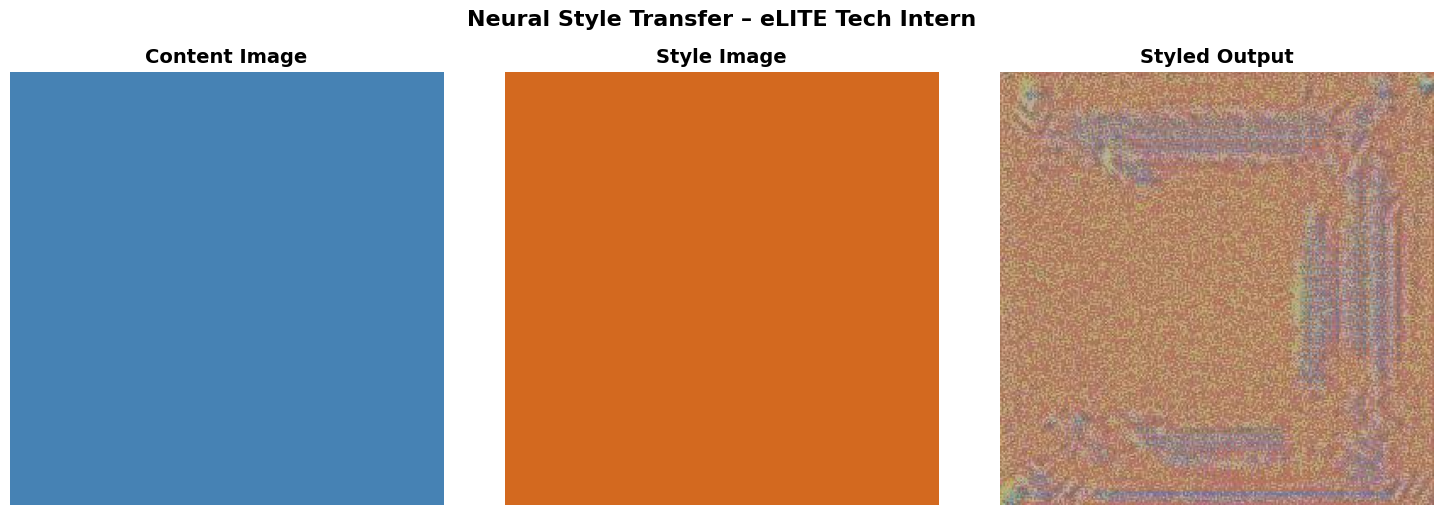

📊  Comparison saved → style_transfer_comparison.png



In [2]:


import os
import copy
import time

try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    import torchvision.transforms as transforms
    import torchvision.models as models
    from PIL import Image
    import matplotlib.pyplot as plt
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False



DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu") if TORCH_AVAILABLE else None
IMAGE_SIZE    = 256          # resize images to this (larger = better but slower)
NUM_STEPS     = 300          # optimisation steps
STYLE_WEIGHT  = 1_000_000   # how strongly to apply the style
CONTENT_WEIGHT = 1           # how strongly to preserve content
STYLE_LAYERS  = ["conv_1", "conv_2", "conv_3", "conv_4", "conv_5"]
CONTENT_LAYER = "conv_4"



def load_image(path: str, size: int = IMAGE_SIZE) -> "torch.Tensor":
    """Load an image from disk and convert to a normalised tensor."""
    transform = transforms.Compose([
        transforms.Resize((size, size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])
    img = Image.open(path).convert("RGB")
    return transform(img).unsqueeze(0).to(DEVICE)


def tensor_to_image(tensor: "torch.Tensor") -> "Image.Image":
    """Convert a model tensor back to a PIL Image."""
    img = tensor.cpu().clone().squeeze(0)
    # De-normalise
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img  = img * std + mean
    img  = img.clamp(0, 1)
    return transforms.ToPILImage()(img)


def create_placeholder_image(color: tuple, size: tuple = (256, 256),
                               path: str = "placeholder.jpg"):
    """Create a solid-colour placeholder image for demo purposes."""
    img = Image.new("RGB", size, color)
    img.save(path)
    return path




class ContentLoss(nn.Module):
    def __init__(self, target: "torch.Tensor"):
        super().__init__()
        self.target = target.detach()
        self.loss   = torch.tensor(0.0)

    def forward(self, x):
        self.loss = nn.functional.mse_loss(x, self.target)
        return x


def gram_matrix(x: "torch.Tensor") -> "torch.Tensor":
    b, c, h, w = x.size()
    features = x.view(b * c, h * w)
    G = torch.mm(features, features.t())
    return G.div(b * c * h * w)


class StyleLoss(nn.Module):
    def __init__(self, target_feature: "torch.Tensor"):
        super().__init__()
        self.target = gram_matrix(target_feature).detach()
        self.loss   = torch.tensor(0.0)

    def forward(self, x):
        self.loss = nn.functional.mse_loss(gram_matrix(x), self.target)
        return x



class Normalization(nn.Module):
    def __init__(self):
        super().__init__()
        self.mean = torch.tensor([0.485, 0.456, 0.406]).to(DEVICE).view(-1, 1, 1)
        self.std  = torch.tensor([0.229, 0.224, 0.225]).to(DEVICE).view(-1, 1, 1)

    def forward(self, x):
        return (x - self.mean) / self.std


def build_model(cnn, style_img, content_img):

    normalization = Normalization().to(DEVICE)
    content_losses = []
    style_losses   = []

    model = nn.Sequential(normalization)

    conv_i = 0
    for layer in cnn.children():
        if isinstance(layer, nn.Conv2d):
            conv_i += 1
            name = f"conv_{conv_i}"
        elif isinstance(layer, nn.ReLU):
            name  = f"relu_{conv_i}"
            layer = nn.ReLU(inplace=False)
        elif isinstance(layer, nn.MaxPool2d):
            name = f"pool_{conv_i}"
        elif isinstance(layer, nn.BatchNorm2d):
            name = f"bn_{conv_i}"
        else:
            continue

        model.add_module(name, layer)

        if name == CONTENT_LAYER:
            target      = model(content_img).detach()
            cl          = ContentLoss(target)
            model.add_module(f"content_loss_{conv_i}", cl)
            content_losses.append(cl)

        if name in STYLE_LAYERS:
            target_feat = model(style_img).detach()
            sl          = StyleLoss(target_feat)
            model.add_module(f"style_loss_{conv_i}", sl)
            style_losses.append(sl)

    # Trim layers after the last loss module
    for i in range(len(model) - 1, -1, -1):
        if isinstance(model[i], (ContentLoss, StyleLoss)):
            break
    model = model[:i + 1]

    return model, style_losses, content_losses



def run_style_transfer(content_path: str,
                       style_path:   str,
                       output_path:  str  = "styled_output.jpg",
                       num_steps:    int  = NUM_STEPS,
                       style_weight: float = STYLE_WEIGHT,
                       content_weight: float = CONTENT_WEIGHT) -> str:

    if not TORCH_AVAILABLE:
        return "❌  Please run: pip install torch torchvision pillow"

    print(f"\n🖼️  Content image : {content_path}")
    print(f"🎨  Style image   : {style_path}")
    print(f"💻  Device        : {DEVICE}")
    print(f"🔁  Steps         : {num_steps}\n")

    content_img = load_image(content_path)
    style_img   = load_image(style_path)

    # Load pre-trained VGG-19 features
    cnn = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1).features.to(DEVICE).eval()
    for param in cnn.parameters():
        param.requires_grad_(False)

    model, style_losses, content_losses = build_model(
        cnn, style_img, content_img
    )

    input_img = content_img.clone()
    optimizer = optim.LBFGS([input_img.requires_grad_(True)])

    step = [0]
    t0   = time.time()

    while step[0] <= num_steps:
        def closure():
            input_img.data.clamp_(0, 1)
            optimizer.zero_grad()
            model(input_img)

            s_loss = sum(sl.loss for sl in style_losses)
            c_loss = sum(cl.loss for cl in content_losses)
            total  = style_weight * s_loss + content_weight * c_loss
            total.backward()

            step[0] += 1
            if step[0] % 50 == 0:
                elapsed = time.time() - t0
                print(f"  Step {step[0]:>4}/{num_steps}  "
                      f"style={s_loss.item():.2f}  "
                      f"content={c_loss.item():.4f}  "
                      f"({elapsed:.1f}s)")
            return total

        optimizer.step(closure)

    input_img.data.clamp_(0, 1)
    out_img = tensor_to_image(input_img)
    out_img.save(output_path)
    print(f"\n✅  Styled image saved → {output_path}")
    return output_path



def show_results(content_path: str,
                 style_path:   str,
                 output_path:  str):
    """Display original / style / output side-by-side with matplotlib."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    titles   = ["Content Image", "Style Image", "Styled Output"]
    paths    = [content_path, style_path, output_path]

    for ax, title, path in zip(axes, titles, paths):
        img = Image.open(path).convert("RGB")
        ax.imshow(img)
        ax.set_title(title, fontsize=14, fontweight="bold")
        ax.axis("off")

    plt.suptitle("Neural Style Transfer – eLITE Tech Intern",
                 fontsize=16, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("style_transfer_comparison.png", bbox_inches="tight")
    plt.show()
    print("📊  Comparison saved → style_transfer_comparison.png")




def run_demo():
    print("=" * 65)

    print("=" * 65)

    if not TORCH_AVAILABLE:
        print("\n❌  Dependencies missing.")
        print("   Run: pip install torch torchvision pillow matplotlib")
        return

    # ── Get image paths ───────────────────────────────────────────
    print("\nProvide paths to your images.")
    print("(Press Enter to use auto-generated placeholder images.)\n")

    content_path = input("📸  Content image path (.jpg / .png): ").strip()
    style_path   = input("🎨  Style image path  (.jpg / .png): ").strip()

    # Create placeholders if not supplied
    if not content_path or not os.path.exists(content_path):
        print("   → Creating placeholder content image (blue gradient)…")
        content_path = create_placeholder_image(
            color=(70, 130, 180), path="content_placeholder.jpg"
        )

    if not style_path or not os.path.exists(style_path):
        print("   → Creating placeholder style image (orange)…")
        style_path = create_placeholder_image(
            color=(210, 105, 30), path="style_placeholder.jpg"
        )

    # ── Hyperparameters ───────────────────────────────────────────
    try:
        steps = int(input("\nNumber of optimisation steps [default 300]: ") or 300)
    except ValueError:
        steps = 300

    output_path = input("Output file name [default styled_output.jpg]: ").strip() \
                  or "styled_output.jpg"

    # ── Run ───────────────────────────────────────────────────────
    result = run_style_transfer(
        content_path, style_path, output_path, num_steps=steps
    )

    if result and not result.startswith("❌"):
        show_results(content_path, style_path, output_path)

    print("\n" + "=" * 65)

    print("=" * 65)


if __name__ == "__main__":
    run_demo()